# 16 — Multi-objective BO over rollout budgets (Modal + Ax)

**Goal:** tune rollout compute budgets — `rollout_h`, `n_rollout_paths`, `candidate_case_radius` — while holding **α** and **ρ** fixed at damped-SW values from notebook 12 / `experiments/tuned_alpha.json`.

**Objectives (MOO):**
- maximize closed-loop **episode profit** (SIM-01=B, rollout arm)
- minimize **rollout wall time** per trial (hard **60 s** cap on the Rust episode only; Modal gets extra budget for cold start)

**Concurrency model:**
- **Ax** proposes up to `AX_PARALLELISM` trials per batch via `get_next_trials(max_trials=…)`; qNEHVI handles multi-objective trade-offs once Sobol initialization finishes.
- Each Ax batch is flattened to **`AX_PARALLELISM × K_BO_SEEDS`** independent shard jobs (trial × seed). One batch completes before the next `get_next_trials` (`MaxTrialsAwaitingData` friendly).
- **Modal:** one `app.run()` per Ax batch; spawn up to `MODAL_CONCURRENCY` containers at a time; `ThreadPoolExecutor` only for concurrent `.get()` (matches `experiments/modal/app.py`).
- **Local:** one `ProcessPoolExecutor` per Ax batch (no nested trial×seed pools); worker count capped at `cpu_count()` to avoid oversubscription.

Inspired by `12_rollout_alpha_bayesian_optimization.ipynb` (Ax plumbing) and T-155 Modal batch patterns (`experiments/modal/app.py`).

**Defaults are smoke-sized.** Set `FULL_RUN = True` for desktop episode length and more BO trials.


## Setup

From the repo root:

```bash
uv sync --extra notebooks --extra viz --extra rust --extra modal --extra data
uv run maturin develop --manifest-path crates/voi_py/Cargo.toml
modal token new   # once, if using Modal
uv run jupyter lab
```

First `uv sync` with `ax-platform` may take several minutes (PyTorch + BoTorch).

After pulling kernel changes, rerun `maturin develop` and **restart the kernel**.


In [1]:
from __future__ import annotations

import json
import os
import time
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, TimeoutError as FuturesTimeoutError, as_completed
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
from ax.api.client import Client
from ax.api.configs import ChoiceParameterConfig, RangeParameterConfig
from tqdm.auto import tqdm

from blueberries_voi.backend import rust_available, rust_core
from blueberries_voi.model import ModelParams
from blueberries_voi.model.demand_profile import load_demand_profile
from blueberries_voi.sim.alpha_tune import evaluate_alpha_episode_outcomes, load_tuned_alpha_table
from blueberries_voi.sim.bakeoff_rollout import DEFAULT_ROLLOUT_HORIZONS
from blueberries_voi.sim.profit import ProfitCosts
from blueberries_voi.sim.shipments import default_shipments, smoke_cool_shipments

# Avoid BLAS/OpenMP oversubscription when batch workers also use threads.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src" / "blueberries_voi").is_dir():
    REPO_ROOT = REPO_ROOT.parent

ARM = "rollout"
FULL_RUN = True
USE_MODAL = True  # True → Modal cloud rollouts (needs `modal token` + wheel build)

# Ax batch concurrency (trials proposed + completed per outer loop)
AX_PARALLELISM = 4 if FULL_RUN else 2
MODAL_CONCURRENCY = 32 if FULL_RUN else 8  # upper bound on simultaneous Modal containers

ROLLOUT_TIMEOUT_S = 420.0  # hard cap on rollout kernel only (excludes Modal cold start)
MODAL_FUNCTION_TIMEOUT_S = ROLLOUT_TIMEOUT_S + 180.0  # Modal @app.function + client .get() budget

if FULL_RUN:
    N_BURN, N_SCORE = 28, 28
    K_BO_SEEDS = 6
    N_AX_TRIALS = 24
    K_VAL_SEEDS = 5
    ROLLOUT_H_BOUNDS = tuple(DEFAULT_ROLLOUT_HORIZONS)
    N_PATHS_BOUNDS = (2, 8)
    RADIUS_BOUNDS = (0, 3)
else:
    N_BURN, N_SCORE = 2, 5
    K_BO_SEEDS = 4
    N_AX_TRIALS = 10
    K_VAL_SEEDS = 3
    ROLLOUT_H_BOUNDS = (7, 14)  # smoke: keep rollouts cheap
    N_PATHS_BOUNDS = (1, 4)
    RADIUS_BOUNDS = (0, 2)

RNG = np.random.default_rng(20260824)
BO_SEEDS = [int(RNG.integers(0, 2**31 - 1)) for _ in range(K_BO_SEEDS)]
VAL_SEEDS = [int(RNG.integers(0, 2**31 - 1)) for _ in range(K_VAL_SEEDS)]

OUTPUT_JSON = REPO_ROOT / "outputs" / "rollout_mobo_modal.json"

rust_fn = getattr(rust_core, "evaluate_alpha_tune_outcomes_py", None) if rust_core else None
print(f"arm: {ARM}")
print(f"Rust kernel: {rust_available() and rust_fn is not None}")
print(f"Modal: {USE_MODAL}")
print(f"episode: n_burn={N_BURN}, n_score={N_SCORE}")
print(f"Ax trials={N_AX_TRIALS}, batch parallelism={AX_PARALLELISM}")
print(f"shard concurrency cap: modal={MODAL_CONCURRENCY}, local={os.cpu_count() or 2}")
print(f"rollout search: H∈{ROLLOUT_H_BOUNDS}, paths∈{N_PATHS_BOUNDS}, radius∈{RADIUS_BOUNDS}")
print(f"rollout cap: {ROLLOUT_TIMEOUT_S:.0f}s; Modal function budget: {MODAL_FUNCTION_TIMEOUT_S:.0f}s")
print(f"BO seeds (K={K_BO_SEEDS}): {BO_SEEDS}")

%matplotlib inline
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3})


arm: rollout
Rust kernel: True
Modal: True
episode: n_burn=28, n_score=28
Ax trials=24, batch parallelism=4
shard concurrency cap: modal=32, local=8
rollout search: H∈(7, 14, 21, 28), paths∈(2, 8), radius∈(0, 3)
rollout cap: 420s; Modal function budget: 600s
BO seeds (K=6): [1891951899, 1876081609, 1803059730, 653908330, 2052231052, 1206495739]


## Fixed α and ρ (SW-tuned; not optimized here)

Rollout inherits the damped-SW base policy. We freeze **α** and **ρ** using, in order:

1. `outputs/sw_alpha_bo.json` from notebook 12 (`ARM = "sw"`, profit SOO) when present
2. `experiments/tuned_alpha.json` (`sw` arm grid search; ρ stays at production default 0.8)

Override `FIXED_ALPHA` / `FIXED_RHO` below if you have T-157 prelim notebook outputs.


In [2]:
SW_BO_JSON = REPO_ROOT / "outputs" / "sw_alpha_bo.json"
TUNED_ALPHA_JSON = REPO_ROOT / "experiments" / "tuned_alpha.json"
DEFAULT_RHO = 0.8

FIXED_ALPHA: float | None = None
FIXED_RHO: float | None = None

if SW_BO_JSON.is_file():
    sw_payload = json.loads(SW_BO_JSON.read_text(encoding="utf-8"))
    FIXED_ALPHA = float(sw_payload.get("best_alpha_profit_soo", sw_payload.get("best_alpha_grid", 0.9)))
    FIXED_RHO = float(sw_payload.get("best_rho_profit_soo", DEFAULT_RHO))
    print(f"Loaded SW BO picks from {SW_BO_JSON.name}: α={FIXED_ALPHA:.4f}, ρ={FIXED_RHO:.4f}")
elif TUNED_ALPHA_JSON.is_file():
    table = load_tuned_alpha_table(TUNED_ALPHA_JSON)
    FIXED_ALPHA = float(table["sw"])
    FIXED_RHO = DEFAULT_RHO
    print(
        f"Loaded tuned α from {TUNED_ALPHA_JSON.name}: α={FIXED_ALPHA:.4f}; "
        f"ρ={FIXED_RHO:.4f} (production default)"
    )
else:
    FIXED_ALPHA = 0.95
    FIXED_RHO = DEFAULT_RHO
    print(f"Fallback constants: α={FIXED_ALPHA:.4f}, ρ={FIXED_RHO:.4f}")

assert FIXED_ALPHA is not None and FIXED_RHO is not None


Loaded tuned α from tuned_alpha.json: α=0.9500; ρ=0.8000 (production default)


## Episode constants

Same economics / demand setup as notebook 12.

In [3]:
UNIT_MARGIN = 2.0
WASTE_COST = 5.0
STOCKOUT_PENALTY = 3.0

costs = ProfitCosts(
    unit_margin=UNIT_MARGIN,
    waste_cost=WASTE_COST,
    stockout_penalty=STOCKOUT_PENALTY,
)

USE_ABDELLA = False
DEMAND_MU = 30.0
DEMAND_VM = 2.0
CASE_SIZE = 8
LEAD_TIME = 1

USE_CALENDAR_DEMAND = True
DEMAND_PROFILE_PATH = REPO_ROOT / "data" / "freshnet" / "demand_profile.json"

_demand_profile = (
    load_demand_profile(DEMAND_PROFILE_PATH) if USE_CALENDAR_DEMAND else None
)
MODEL_PARAMS = ModelParams(
    demand_mu=DEMAND_MU,
    demand_vm=DEMAND_VM,
    case_size=CASE_SIZE,
    demand_profile=_demand_profile,
)

shipments = default_shipments() if USE_ABDELLA else smoke_cool_shipments()

EPISODE_KWARGS: dict[str, Any] = {
    "params": MODEL_PARAMS,
    "shipments": shipments,
    "costs": costs,
    "n_burn": N_BURN,
    "n_score": N_SCORE,
    "lead_time": LEAD_TIME,
}

print(f"fixed policy: α={FIXED_ALPHA:.4f}, ρ={FIXED_RHO:.4f}")
print(f"calendar demand: {USE_CALENDAR_DEMAND}")


fixed policy: α=0.9500, ρ=0.8000
calendar demand: True


## Evaluation worker (local + Modal)

Each Ax trial evaluates one rollout budget vector on **K demand seeds**. We report:
- `episode_profit`: replicate mean ± SEM (maximize)
- `wall_time_s`: replicate mean wall time (minimize; 60 s hard cap)

**Batch parallelism:** one Ax batch flattens to `len(trials) × len(seeds)` shard jobs. Modal uses a single `app.run()` per batch (see `experiments/modal/app.py`); local uses one `ProcessPoolExecutor` per batch.

In [4]:
@dataclass(frozen=True)
class TrialEvalResult:
    ok: bool
    profit_mean: float
    profit_sem: float
    wall_mean: float
    wall_sem: float
    timed_out: bool
    error: str | None = None


def _replicate_mean_sem(values: list[float]) -> tuple[float, float]:
    arr = np.asarray(values, dtype=float)
    mean = float(arr.mean())
    sem = float(arr.std(ddof=1) / np.sqrt(len(arr))) if len(arr) > 1 else 0.0
    return mean, sem


def _evaluate_seed_job(job: dict[str, Any]) -> dict[str, Any]:
    """One (trial, seed) shard — picklable for ProcessPoolExecutor workers."""
    try:
        params = ModelParams(
            demand_mu=float(job["demand_mu"]),
            demand_vm=float(job["demand_vm"]),
            case_size=int(job["case_size"]),
            demand_profile=(
                load_demand_profile(job["demand_profile_path"])
                if job.get("use_calendar_demand")
                else None
            ),
        )
        shipments = (
            default_shipments()
            if job.get("use_abdella")
            else smoke_cool_shipments()
        )
        costs = ProfitCosts(
            unit_margin=float(job["unit_margin"]),
            waste_cost=float(job["waste_cost"]),
            stockout_penalty=float(job["stockout_penalty"]),
        )
        t0 = time.perf_counter()
        out = evaluate_alpha_episode_outcomes(
            job["arm"],
            float(job["alpha"]),
            int(job["root_seed"]),
            rho=float(job["rho"]),
            params=params,
            shipments=shipments,
            costs=costs,
            n_burn=int(job["n_burn"]),
            n_score=int(job["n_score"]),
            lead_time=int(job["lead_time"]),
            rollout_h=int(job["rollout_h"]),
            n_rollout_paths=int(job["n_rollout_paths"]),
            candidate_case_radius=int(job["candidate_case_radius"]),
        )
        elapsed = time.perf_counter() - t0
        timeout_s = float(job["timeout_s"])
        if elapsed > timeout_s:
            msg = f"evaluation exceeded {timeout_s:.0f}s ({elapsed:.1f}s)"
            raise TimeoutError(msg)
        return {
            "trial_index": int(job["trial_index"]),
            "root_seed": int(job["root_seed"]),
            "ok": True,
            "profit": float(out.profit),
            "wall_s": float(elapsed),
            "timed_out": False,
            "error": None,
        }
    except Exception as exc:  # pragma: no cover - notebook diagnostics
        return {
            "trial_index": int(job["trial_index"]),
            "root_seed": int(job["root_seed"]),
            "ok": False,
            "profit": 0.0,
            "wall_s": float(job["timeout_s"]),
            "timed_out": isinstance(exc, (TimeoutError, FuturesTimeoutError)),
            "error": str(exc),
        }


def _job_payload(
    *,
    trial_index: int,
    rollout_h: int,
    n_rollout_paths: int,
    candidate_case_radius: int,
    root_seed: int,
) -> dict[str, Any]:
    return {
        "trial_index": int(trial_index),
        "arm": ARM,
        "alpha": float(FIXED_ALPHA),
        "rho": float(FIXED_RHO),
        "root_seed": int(root_seed),
        "rollout_h": int(rollout_h),
        "n_rollout_paths": int(n_rollout_paths),
        "candidate_case_radius": int(candidate_case_radius),
        "n_burn": int(N_BURN),
        "n_score": int(N_SCORE),
        "lead_time": int(LEAD_TIME),
        "unit_margin": float(UNIT_MARGIN),
        "waste_cost": float(WASTE_COST),
        "stockout_penalty": float(STOCKOUT_PENALTY),
        "demand_mu": float(DEMAND_MU),
        "demand_vm": float(DEMAND_VM),
        "case_size": int(CASE_SIZE),
        "use_calendar_demand": bool(USE_CALENDAR_DEMAND),
        "demand_profile_path": _MODAL_DEMAND_PROFILE if USE_MODAL else str(DEMAND_PROFILE_PATH),
        "use_abdella": bool(USE_ABDELLA),
        "timeout_s": float(ROLLOUT_TIMEOUT_S),
    }


def _build_batch_jobs(
    trials: dict[int, dict[str, object]],
    seeds: list[int],
) -> list[dict[str, Any]]:
    jobs: list[dict[str, Any]] = []
    for trial_index, params in trials.items():
        rollout_h = int(params["rollout_h"])
        n_rollout_paths = int(params["n_rollout_paths"])
        candidate_case_radius = int(params["candidate_case_radius"])
        for seed in seeds:
            jobs.append(
                _job_payload(
                    trial_index=int(trial_index),
                    rollout_h=rollout_h,
                    n_rollout_paths=n_rollout_paths,
                    candidate_case_radius=candidate_case_radius,
                    root_seed=int(seed),
                )
            )
    return jobs


def _aggregate_shards(shards: list[dict[str, Any]]) -> dict[int, TrialEvalResult]:
    by_trial: dict[int, list[dict[str, Any]]] = {}
    for shard in shards:
        by_trial.setdefault(int(shard["trial_index"]), []).append(shard)

    out: dict[int, TrialEvalResult] = {}
    for trial_index, rows in by_trial.items():
        failed = [row for row in rows if not row["ok"]]
        if failed:
            err_row = failed[0]
            out[trial_index] = TrialEvalResult(
                ok=False,
                profit_mean=0.0,
                profit_sem=0.0,
                wall_mean=ROLLOUT_TIMEOUT_S,
                wall_sem=0.0,
                timed_out=bool(err_row.get("timed_out")),
                error=str(err_row.get("error") or "rollout timeout"),
            )
            continue
        profits = [float(row["profit"]) for row in rows]
        walls = [float(row["wall_s"]) for row in rows]
        p_mean, p_sem = _replicate_mean_sem(profits)
        w_mean, w_sem = _replicate_mean_sem(walls)
        out[trial_index] = TrialEvalResult(
            ok=True,
            profit_mean=p_mean,
            profit_sem=p_sem,
            wall_mean=w_mean,
            wall_sem=w_sem,
            timed_out=False,
        )
    return out


def _evaluate_batch_local(jobs: list[dict[str, Any]]) -> list[dict[str, Any]]:
    if not jobs:
        return []
    max_workers = min(len(jobs), os.cpu_count() or 2)
    shards: list[dict[str, Any]] = []
    with ProcessPoolExecutor(max_workers=max_workers) as pool:
        futs = {pool.submit(_evaluate_seed_job, job): job for job in jobs}
        for fut in as_completed(futs):
            job = futs[fut]
            try:
                shard = fut.result(timeout=ROLLOUT_TIMEOUT_S + 30.0)
            except (FuturesTimeoutError, TimeoutError) as exc:
                shard = {
                    "trial_index": int(job["trial_index"]),
                    "root_seed": int(job["root_seed"]),
                    "ok": False,
                    "profit": 0.0,
                    "wall_s": float(ROLLOUT_TIMEOUT_S),
                    "timed_out": True,
                    "error": str(exc),
                }
            shards.append(shard)
    return shards


# --- Modal worker (optional) ---
modal_rollout_shard = None
if USE_MODAL:
    try:
        import modal
    except ImportError as exc:
        raise SystemExit(
            "Install modal: uv sync --extra modal"
        ) from exc

    _PKG_SRC = REPO_ROOT / "src" / "blueberries_voi"
    _DATA_DIR = REPO_ROOT / "data"
    _WHEEL_DIR = Path(os.environ.get("BLUEBERRIES_VOI_WHEEL", REPO_ROOT / "dist" / "wheel"))
    if _WHEEL_DIR.is_dir():
        _wheel_files = sorted(_WHEEL_DIR.glob("blueberries_voi_core-*.whl"))
        WHEEL_PATH = _wheel_files[-1] if _wheel_files else (_WHEEL_DIR / "blueberries_voi_core.whl")
    else:
        WHEEL_PATH = _WHEEL_DIR
    _WHEEL_REMOTE = f"/tmp/{WHEEL_PATH.name}"

    # uv_sync: lockfile deps from pyproject.toml (+ data extra → pyarrow).
    # Does not install the project or Rust extension; those are added below.
    _UV_PROJECT_DIR = os.path.relpath(REPO_ROOT, Path.cwd().resolve())
    if _UV_PROJECT_DIR == os.curdir:
        _UV_PROJECT_DIR = "."

    _MODAL_DEMAND_PROFILE = "/data/freshnet/demand_profile.json"

    _thread_env = {
        "PYTHONPATH": "/root",
        "BLUEBERRIES_VOI_BACKEND": "rust",
        "OMP_NUM_THREADS": "1",
        "MKL_NUM_THREADS": "1",
        "OPENBLAS_NUM_THREADS": "1",
    }
    _base_image = modal.Image.debian_slim(python_version="3.11").uv_sync(
        uv_project_dir=_UV_PROJECT_DIR,
        extras=["data"],
        frozen=True,
    )
    if modal.is_local():
        image = _base_image.add_local_dir(
            str(_PKG_SRC), remote_path="/root/blueberries_voi", copy=True
        )
        image = image.add_local_dir(str(_DATA_DIR), remote_path="/data", copy=True)
        if WHEEL_PATH.is_file():
            image = image.add_local_file(str(WHEEL_PATH), _WHEEL_REMOTE, copy=True)
            image = image.run_commands(f"pip install {_WHEEL_REMOTE}")
        image = image.env(_thread_env)
    else:
        image = _base_image.env(_thread_env)

    app = modal.App("blueberries-voi-rollout-mobo", image=image)

    @app.function(timeout=int(MODAL_FUNCTION_TIMEOUT_S), cpu=1.0)
    def rollout_shard(job: dict[str, Any]) -> dict[str, Any]:
        from blueberries_voi.model import ModelParams
        from blueberries_voi.model.demand_profile import load_demand_profile
        from blueberries_voi.sim.alpha_tune import evaluate_alpha_episode_outcomes
        from blueberries_voi.sim.profit import ProfitCosts
        from blueberries_voi.sim.shipments import default_shipments, smoke_cool_shipments

        try:
            profile = None
            if job.get("use_calendar_demand"):
                profile = load_demand_profile(job["demand_profile_path"])
            params = ModelParams(
                demand_mu=float(job["demand_mu"]),
                demand_vm=float(job["demand_vm"]),
                case_size=int(job["case_size"]),
                demand_profile=profile,
            )
            ships = (
                default_shipments()
                if job.get("use_abdella")
                else smoke_cool_shipments()
            )
            costs = ProfitCosts(
                unit_margin=float(job["unit_margin"]),
                waste_cost=float(job["waste_cost"]),
                stockout_penalty=float(job["stockout_penalty"]),
            )
            t0 = time.perf_counter()
            out = evaluate_alpha_episode_outcomes(
                job["arm"],
                float(job["alpha"]),
                int(job["root_seed"]),
                rho=float(job["rho"]),
                params=params,
                shipments=ships,
                costs=costs,
                n_burn=int(job["n_burn"]),
                n_score=int(job["n_score"]),
                lead_time=int(job["lead_time"]),
                rollout_h=int(job["rollout_h"]),
                n_rollout_paths=int(job["n_rollout_paths"]),
                candidate_case_radius=int(job["candidate_case_radius"]),
            )
            elapsed = time.perf_counter() - t0
            timeout_s = float(job["timeout_s"])
            if elapsed > timeout_s:
                msg = f"evaluation exceeded {timeout_s:.0f}s ({elapsed:.1f}s)"
                raise TimeoutError(msg)
            return {
                "trial_index": int(job["trial_index"]),
                "root_seed": int(job["root_seed"]),
                "ok": True,
                "profit": float(out.profit),
                "wall_s": float(elapsed),
                "timed_out": False,
                "error": None,
            }
        except Exception as exc:  # pragma: no cover - notebook diagnostics
            return {
                "trial_index": int(job["trial_index"]),
                "root_seed": int(job["root_seed"]),
                "ok": False,
                "profit": 0.0,
                "wall_s": float(job["timeout_s"]),
                "timed_out": isinstance(exc, TimeoutError),
                "error": str(exc),
            }

    modal_rollout_shard = rollout_shard


def _evaluate_batch_modal(jobs: list[dict[str, Any]]) -> list[dict[str, Any]]:
    assert modal_rollout_shard is not None
    if not jobs:
        return []

    shards: list[dict[str, Any]] = []
    with app.run():
        for chunk_start in range(0, len(jobs), MODAL_CONCURRENCY):
            chunk = jobs[chunk_start : chunk_start + MODAL_CONCURRENCY]
            handles = [(job, modal_rollout_shard.spawn(job)) for job in chunk]
            with ThreadPoolExecutor(max_workers=len(handles)) as pool:
                futs = {
                    pool.submit(
                        h.get,
                        timeout=MODAL_FUNCTION_TIMEOUT_S + 10.0,
                    ): (job, h)
                    for job, h in handles
                }
                for fut in as_completed(futs):
                    job, _handle = futs[fut]
                    try:
                        shard = fut.result()
                    except Exception as exc:  # Modal timeout / worker failure
                        shards.append(
                            {
                                "trial_index": int(job["trial_index"]),
                                "root_seed": int(job["root_seed"]),
                                "ok": False,
                                "profit": 0.0,
                                "wall_s": float(ROLLOUT_TIMEOUT_S),
                                "timed_out": True,
                                "error": str(exc),
                            }
                        )
                        continue
                    if shard.get("timed_out") or not shard.get("ok", True):
                        shard = {
                            **shard,
                            "ok": False,
                            "timed_out": True,
                            "error": shard.get("error")
                            or f"shard exceeded {ROLLOUT_TIMEOUT_S:.0f}s",
                        }
                    shards.append(shard)
    return shards


def evaluate_ax_batch(
    trials: dict[int, dict[str, object]],
    seeds: list[int] | None = None,
) -> dict[int, TrialEvalResult]:
    """Evaluate all trials in one Ax batch with flat shard parallelism."""
    seed_list = list(seeds or BO_SEEDS)
    jobs = _build_batch_jobs(trials, seed_list)
    if not jobs:
        return {}
    if USE_MODAL:
        shards = _evaluate_batch_modal(jobs)
    else:
        shards = _evaluate_batch_local(jobs)
    return _aggregate_shards(shards)


def evaluate_rollout_budget(
    rollout_h: int,
    n_rollout_paths: int,
    candidate_case_radius: int,
    seeds: list[int] | None = None,
) -> TrialEvalResult:
    """Single-trial helper (validation). Uses the same flat batch path."""
    trials = {
        0: {
            "rollout_h": int(rollout_h),
            "n_rollout_paths": int(n_rollout_paths),
            "candidate_case_radius": int(candidate_case_radius),
        }
    }
    return evaluate_ax_batch(trials, seeds=list(seeds or BO_SEEDS))[0]


# smoke: local quick check (BO loop still respects USE_MODAL)
smoke = evaluate_rollout_budget(
    rollout_h=7,
    n_rollout_paths=2,
    candidate_case_radius=1,
    seeds=BO_SEEDS[:2],
)
print(
    f"smoke H=7 P=2 r=1 on 2 seeds: profit={smoke.profit_mean:.2f}±{smoke.profit_sem:.3f}, "
    f"wall={smoke.wall_mean:.2f}s, ok={smoke.ok}"
)


smoke H=7 P=2 r=1 on 2 seeds: profit=955.50±85.500, wall=75.65s, ok=True


## Ax multi-objective BO loop (batched concurrency)

Ax concurrency rules (see [Automating Orchestration](https://ax.dev/docs/tutorials/automating/)):
- Request **`AX_PARALLELISM`** candidates per batch with `get_next_trials(max_trials=…)`.
- Finish (or fail) the whole batch before asking for more — keeps `MaxTrialsAwaitingData` low and lets qNEHVI see fresh observations.
- **`evaluate_ax_batch`** runs all `trial × seed` shards in one flat pool (Modal or local); no nested trial threads or per-trial `app.run()`.

Objectives: `episode_profit` (maximize) and `-wall_time_s` (minimize runtime).

In [5]:
def ax_rollout_parameter_configs() -> list[ChoiceParameterConfig | RangeParameterConfig]:
    return [
        ChoiceParameterConfig(
            name="rollout_h",
            parameter_type="int",
            values=list(ROLLOUT_H_BOUNDS),
            is_ordered=True,
        ),
        RangeParameterConfig(
            name="n_rollout_paths",
            parameter_type="int",
            bounds=N_PATHS_BOUNDS,
        ),
        RangeParameterConfig(
            name="candidate_case_radius",
            parameter_type="int",
            bounds=RADIUS_BOUNDS,
        ),
    ]


AX_JSON = REPO_ROOT / "outputs" / "rollout_mobo_ax_client.json"
RELOAD_AX = False  # True → skip BO; load AX_JSON in a fresh kernel

if RELOAD_AX and AX_JSON.is_file():
    client = Client.load_from_json_file(str(AX_JSON))
    pareto = client.get_pareto_frontier()
    trial_log: list[dict[str, Any]] = []
    print(
        f"Loaded Ax client from {AX_JSON.name} "
        f"({len(client._experiment.trials)} trials, Pareto={len(pareto)})"
    )
else:
    RELOAD_AX = False
    client = Client()
    client.configure_experiment(
        name="rollout-mobo-modal",
        parameters=ax_rollout_parameter_configs(),
    )
    client.configure_optimization(objective="episode_profit, -wall_time_s")

    trial_log = []
    completed = 0
    pbar = tqdm(total=N_AX_TRIALS, desc="Ax rollout MOBO")

    while completed < N_AX_TRIALS:
        batch_n = min(AX_PARALLELISM, N_AX_TRIALS - completed)
        trials = client.get_next_trials(max_trials=batch_n)
        batch_results = evaluate_ax_batch(trials, seeds=BO_SEEDS)

        for trial_index, params in trials.items():
            result = batch_results.get(
                trial_index,
                TrialEvalResult(
                    ok=False,
                    profit_mean=0.0,
                    profit_sem=0.0,
                    wall_mean=ROLLOUT_TIMEOUT_S,
                    wall_sem=0.0,
                    timed_out=True,
                    error="missing shard results",
                ),
            )
            rollout_h = int(params["rollout_h"])
            n_paths = int(params["n_rollout_paths"])
            radius = int(params["candidate_case_radius"])

            if not result.ok:
                client.mark_trial_failed(
                    trial_index,
                    failed_reason=result.error or "rollout timeout",
                )
            else:
                client.complete_trial(
                    trial_index=trial_index,
                    raw_data={
                        "episode_profit": (result.profit_mean, result.profit_sem),
                        "wall_time_s": (result.wall_mean, result.wall_sem),
                    },
                )

            trial_log.append(
                {
                    "trial_index": int(trial_index),
                    "rollout_h": rollout_h,
                    "n_rollout_paths": n_paths,
                    "candidate_case_radius": radius,
                    "mean_profit": result.profit_mean,
                    "sem_profit": result.profit_sem,
                    "mean_wall_s": result.wall_mean,
                    "sem_wall_s": result.wall_sem,
                    "ok": result.ok,
                    "timed_out": result.timed_out,
                }
            )
            completed += 1
            pbar.update(1)

    pbar.close()
    pareto = client.get_pareto_frontier()

print(f"Pareto frontier size: {len(pareto)}")
for parameters, metric_vals, trial_index, _arm in pareto[:8]:
    print(
        f"  trial {trial_index} H={parameters['rollout_h']} P={parameters['n_rollout_paths']} "
        f"r={parameters['candidate_case_radius']} profit={metric_vals['episode_profit'][0]:.1f} "
        f"wall={metric_vals['wall_time_s'][0]:.2f}s"
    )


Ax rollout MOBO:   0%|          | 0/24 [00:00<?, ?it/s]

[INFO 08-24 21:05:00] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol', use_existing_trials_for_initialization=True), GenerationNode(name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, generator_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')], suggested_experiment_status=ExperimentStatus.INITIALIZATION, pausing_criteria=[MaxTrialsAwaitingData(threshold=5)]), GenerationNode(name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, generator_key_override=None)], transition_criteria=None, suggested_experiment_status=ExperimentStatus.OPTIMIZATION, pausing_criteria=None)]) chosen based on user input and problem structure.
[INFO 08-24 21:05:00] ax.api.client: Generated new trial 0 with parameters {'rollout_h': 21, 'n_rollout_paths': 5, 'candidate_case_radius': 1} using GenerationNode CenterOfSearchSpace.
[INFO 08-24 21:05:00] ax.api.client: Gener

Pareto frontier size: 5
  trial 15 H=28 P=2 r=0 profit=850.8 wall=24.16s
  trial 10 H=14 P=2 r=1 profit=851.3 wall=71.00s
  trial 9 H=21 P=2 r=0 profit=850.7 wall=23.47s
  trial 20 H=28 P=2 r=1 profit=851.6 wall=76.71s
  trial 22 H=7 P=2 r=1 profit=851.0 wall=69.00s


## Save Ax client snapshot

Persists experiment + generation strategy so you can reload after a kernel death without re-running Modal.

In [ ]:
if not RELOAD_AX:
    AX_JSON.parent.mkdir(parents=True, exist_ok=True)
    client.save_to_json_file(str(AX_JSON))
    print(f"Saved Ax client → {AX_JSON}")
else:
    print(f"Using reloaded client from {AX_JSON}")

## Ax built-in visualizations

Plotly scatter / parallel coordinates / marginal effects / contours, plus summary cards.

In [ ]:
from IPython.display import display

from ax.analysis import BestTrials, Summary
from ax.analysis.plotly import (
    ContourPlot,
    MarginalEffectsPlot,
    ParallelCoordinatesPlot,
    ScatterPlot,
)

summary_df = client.summarize()
display(summary_df)

ax_analyses = [
    ScatterPlot(
        x_metric_name="wall_time_s",
        y_metric_name="episode_profit",
        use_model_predictions=False,
        show_pareto_frontier=True,
        title="MOO: profit vs rollout wall time",
    ),
    ParallelCoordinatesPlot(metric_name="episode_profit"),
    ParallelCoordinatesPlot(metric_name="wall_time_s"),
    MarginalEffectsPlot(metric_name="episode_profit"),
    ContourPlot(
        x_parameter_name="n_rollout_paths",
        y_parameter_name="candidate_case_radius",
        metric_name="episode_profit",
    ),
    ContourPlot(
        x_parameter_name="n_rollout_paths",
        y_parameter_name="candidate_case_radius",
        metric_name="wall_time_s",
    ),
    BestTrials(),
    Summary(),
]

ax_cards = client.compute_analyses(analyses=ax_analyses, display=False)
for card in ax_cards:
    display(card)

## Matplotlib diagnostics

Trial-log views (failures/timeouts included).

In [ ]:
ok_trials = [t for t in trial_log if t["ok"]]
fail_trials = [t for t in trial_log if not t["ok"]]

if not ok_trials and RELOAD_AX:
    print("trial_log empty after RELOAD_AX — use Ax cards above or client.summarize().")
elif not ok_trials:
    print("No successful trials to plot.")
else:
    profits = np.array([t["mean_profit"] for t in ok_trials])
    walls = np.array([t["mean_wall_s"] for t in ok_trials])
    paths = np.array([t["n_rollout_paths"] for t in ok_trials])
    hs = np.array([t["rollout_h"] for t in ok_trials])
    rs = np.array([t["candidate_case_radius"] for t in ok_trials])
    tidx = np.array([t["trial_index"] for t in ok_trials])

    pareto_idx = {int(trial_index) for _, _, trial_index, _ in pareto} if pareto else set()
    on_pf = np.array([ti in pareto_idx for ti in tidx])

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    ax = axes[0, 0]
    sc = ax.scatter(walls, profits, c=paths, cmap="viridis", s=55, alpha=0.85)
    if pareto:
        pw = [m["wall_time_s"][0] for _, m, _, _ in pareto]
        pp = [m["episode_profit"][0] for _, m, _, _ in pareto]
        ax.scatter(
            pw, pp, facecolors="none", edgecolors="#16a34a", s=140, linewidths=2, label="Pareto"
        )
    ax.set_xlabel("Rollout wall time (s)")
    ax.set_ylabel("Episode profit")
    ax.set_title("Profit vs runtime")
    fig.colorbar(sc, ax=ax, label="n_rollout_paths")
    ax.legend(fontsize=8)

    ax = axes[0, 1]
    sc2 = ax.scatter(hs, rs, c=profits, cmap="plasma", s=55, alpha=0.85)
    ax.set_xlabel("rollout_h")
    ax.set_ylabel("candidate_case_radius")
    ax.set_title("Search space (color=profit)")
    fig.colorbar(sc2, ax=ax, label="profit")

    ax = axes[0, 2]
    ax.scatter(paths, hs, c=walls, cmap="magma", s=55, alpha=0.85)
    ax.set_xlabel("n_rollout_paths")
    ax.set_ylabel("rollout_h")
    ax.set_title("Budget combos (color=wall s)")

    ax = axes[1, 0]
    ax.scatter(tidx, profits, c=on_pf, cmap="coolwarm", s=55, alpha=0.85)
    ax.set_xlabel("Ax trial index")
    ax.set_ylabel("Episode profit")
    ax.set_title("Profit by trial")

    ax = axes[1, 1]
    ax.scatter(tidx, walls, s=55, alpha=0.85)
    ax.axhline(
        ROLLOUT_TIMEOUT_S,
        color="#dc2626",
        ls="--",
        lw=1,
        label=f"rollout cap {ROLLOUT_TIMEOUT_S:.0f}s",
    )
    ax.set_xlabel("Ax trial index")
    ax.set_ylabel("Rollout wall time (s)")
    ax.set_title("Runtime by trial")
    ax.legend(fontsize=8)

    ax = axes[1, 2]
    ax.hist(walls, bins=min(12, max(3, len(walls) // 2)), alpha=0.85)
    ax.axvline(ROLLOUT_TIMEOUT_S, color="#dc2626", ls="--", lw=1)
    ax.set_xlabel("Rollout wall time (s)")
    ax.set_ylabel("Count")
    ax.set_title("Runtime distribution")

    title = f"Rollout MOBO — fixed α={FIXED_ALPHA:.3f}, ρ={FIXED_RHO:.3f}"
    if fail_trials:
        title = f"{title} ({len(ok_trials)} ok, {len(fail_trials)} failed)"
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()

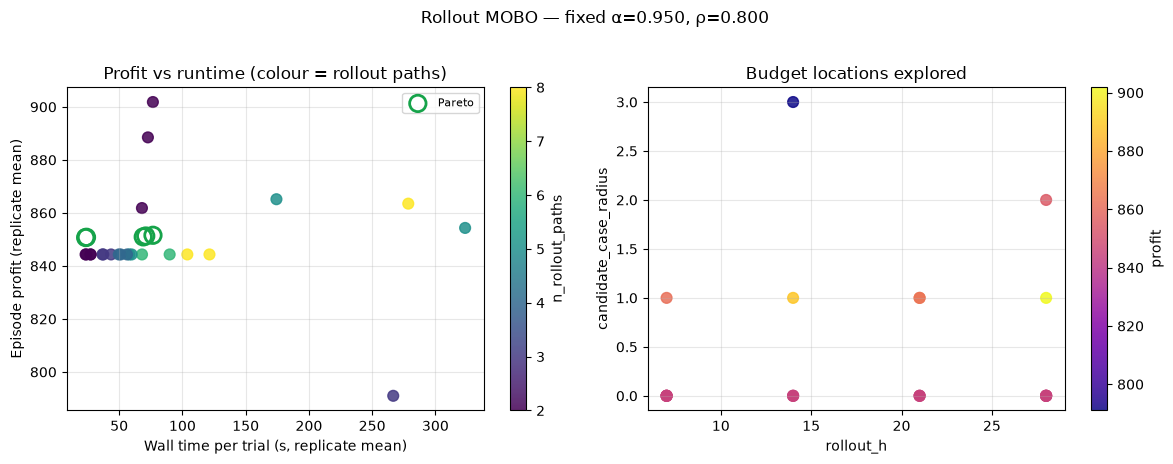

In [6]:
profits = np.array([t["mean_profit"] for t in trial_log if t["ok"]])
walls = np.array([t["mean_wall_s"] for t in trial_log if t["ok"]])
paths = np.array([t["n_rollout_paths"] for t in trial_log if t["ok"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
if len(profits):
    sc = ax.scatter(walls, profits, c=paths, cmap="viridis", s=60, alpha=0.85)
    fig.colorbar(sc, ax=ax, label="n_rollout_paths")
if pareto:
    pw = [m["wall_time_s"][0] for _, m, _, _ in pareto]
    pp = [m["episode_profit"][0] for _, m, _, _ in pareto]
    ax.scatter(pw, pp, facecolors="none", edgecolors="#16a34a", s=140, linewidths=2, label="Pareto")
ax.set_xlabel("Wall time per trial (s, replicate mean)")
ax.set_ylabel("Episode profit (replicate mean)")
ax.set_title("Profit vs runtime (colour = rollout paths)")
ax.legend(fontsize=8)

ax = axes[1]
hs = [t["rollout_h"] for t in trial_log if t["ok"]]
rs = [t["candidate_case_radius"] for t in trial_log if t["ok"]]
if hs:
    sc2 = ax.scatter(hs, rs, c=profits if len(profits) else "k", cmap="plasma", s=60, alpha=0.85)
    fig.colorbar(sc2, ax=ax, label="profit")
ax.set_xlabel("rollout_h")
ax.set_ylabel("candidate_case_radius")
ax.set_title("Budget locations explored")

fig.suptitle(
    f"Rollout MOBO — fixed α={FIXED_ALPHA:.3f}, ρ={FIXED_RHO:.3f}",
    y=1.02,
)
fig.tight_layout()
plt.show()


## Validation on held-out seeds

In [7]:
def validation_means(params: dict[str, int]) -> tuple[float, float]:
    out = evaluate_rollout_budget(
        rollout_h=int(params["rollout_h"]),
        n_rollout_paths=int(params["n_rollout_paths"]),
        candidate_case_radius=int(params["candidate_case_radius"]),
        seeds=VAL_SEEDS,
    )
    return out.profit_mean, out.wall_mean


if pareto:
    best_tradeoff = dict(pareto[0][0])
    v_profit, v_wall = validation_means(best_tradeoff)
    print(
        "Validation (first Pareto point): "
        f"H={best_tradeoff['rollout_h']} P={best_tradeoff['n_rollout_paths']} "
        f"r={best_tradeoff['candidate_case_radius']} → profit={v_profit:.2f}, wall={v_wall:.2f}s"
    )
else:
    best_tradeoff = {}
    print("No successful Pareto points — widen smoke budgets or disable Modal for debugging.")


Validation (first Pareto point): H=28 P=2 r=0 → profit=717.80, wall=27.04s


## Persist results

In [8]:
payload: dict[str, Any] = {
    "arm": ARM,
    "fixed_alpha": float(FIXED_ALPHA),
    "fixed_rho": float(FIXED_RHO),
    "full_run": FULL_RUN,
    "use_modal": USE_MODAL,
    "ax_parallelism": AX_PARALLELISM,
    "modal_concurrency": MODAL_CONCURRENCY,
    "rollout_timeout_s": ROLLOUT_TIMEOUT_S,
    "modal_function_timeout_s": MODAL_FUNCTION_TIMEOUT_S,
    "n_burn": N_BURN,
    "n_score": N_SCORE,
    "bo_seeds": BO_SEEDS,
    "val_seeds": VAL_SEEDS,
    "search_bounds": {
        "rollout_h": list(ROLLOUT_H_BOUNDS),
        "n_rollout_paths": list(N_PATHS_BOUNDS),
        "candidate_case_radius": list(RADIUS_BOUNDS),
    },
    "trials": trial_log,
    "pareto_size": len(pareto),
}
OUTPUT_JSON.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_JSON.write_text(json.dumps(payload, indent=2) + "\n", encoding="utf-8")
print(f"Wrote {OUTPUT_JSON}")


Wrote /home/oliver/blog/blueberries-voi/.worktrees/16-rollout-mobo-modal/outputs/rollout_mobo_modal.json
